# Task 1 — Coarse-Grained Animal Classification
COMP30027 Machine Learning 2026 — Project 2

## 1. Import Libraries

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Display settings
pd.set_option('display.max_columns', 20)
%matplotlib inline

## 2. Load Data

In [92]:
DATA_DIR = Path('task1_data')

# Metadata
train_meta = pd.read_csv(DATA_DIR / 'train_metadata.csv')
test_meta  = pd.read_csv(DATA_DIR / 'test_metadata.csv')

# Feature CSVs — index by image_id so we can look up rows by ID later
color_hist = pd.read_csv(DATA_DIR / 'color_histogram.csv',     index_col='image_id')
hog_pca    = pd.read_csv(DATA_DIR / 'hog_pca.csv',             index_col='image_id')
add_feat   = pd.read_csv(DATA_DIR / 'additional_features.csv', index_col='image_id')

print(f'Train samples : {len(train_meta)}')
print(f'Test  samples : {len(test_meta)}')
print(f'color_histogram   : {color_hist.shape}')
print(f'hog_pca           : {hog_pca.shape}')
print(f'additional_features: {add_feat.shape}')

Train samples : 3750
Test  samples : 1250
color_histogram   : (5000, 96)
hog_pca           : (5000, 100)
additional_features: (5000, 23)


In [93]:
# Preview metadata
train_meta.head()

,image_id,image_path,class_id,class_name
0,train_bird_00000,images/train/bird/bird_00000.png,0,bird
1,train_bird_00001,images/train/bird/bird_00001.png,0,bird
2,train_bird_00002,images/train/bird/bird_00002.png,0,bird
3,train_bird_00003,images/train/bird/bird_00003.png,0,bird
4,train_bird_00004,images/train/bird/bird_00004.png,0,bird


In [94]:
test_meta.head()

,image_id,image_path
0,test_00000,images/test/test_00000.png
1,test_00001,images/test/test_00001.png
2,test_00002,images/test/test_00002.png
3,test_00003,images/test/test_00003.png
4,test_00004,images/test/test_00004.png


## 3. Data Quality Checks

In [95]:
# Check for missing values across all dataframes
for name, df in [('train_meta', train_meta), ('test_meta', test_meta),
                 ('color_hist', color_hist), ('hog_pca', hog_pca), ('add_feat', add_feat)]:
    nulls = df.isnull().sum().sum()
    print(f'{name:20s}  missing values: {nulls}')

train_meta            missing values: 0
test_meta             missing values: 0
color_hist            missing values: 0
hog_pca               missing values: 0
add_feat              missing values: 0


In [96]:
# Confirm feature CSVs cover all train + test images (should be 3750 + 1250 = 5000 rows)
all_ids    = list(train_meta['image_id']) + list(test_meta['image_id'])
in_color   = set(color_hist.index)
in_hog     = set(hog_pca.index)
in_add     = set(add_feat.index)

missing_color = [i for i in all_ids if i not in in_color]
missing_hog   = [i for i in all_ids if i not in in_hog]
missing_add   = [i for i in all_ids if i not in in_add]

print(f'IDs missing from color_histogram   : {len(missing_color)}')
print(f'IDs missing from hog_pca           : {len(missing_hog)}')
print(f'IDs missing from additional_features: {len(missing_add)}')

IDs missing from color_histogram   : 0
IDs missing from hog_pca           : 0
IDs missing from additional_features: 0


## 4. Explore the Training Labels

In [97]:
# Class distribution
class_counts = train_meta['class_name'].value_counts().sort_index()
print(class_counts)
print(f'\nTotal classes : {train_meta["class_name"].nunique()}')
print(f'Min per class : {class_counts.min()}')
print(f'Max per class : {class_counts.max()}')

class_name
bird         375
butterfly    375
cat          375
deer         375
dog          375
elephant     375
frog         375
horse        375
sheep        375
spider       375
Name: count, dtype: int64

Total classes : 10
Min per class : 375
Max per class : 375


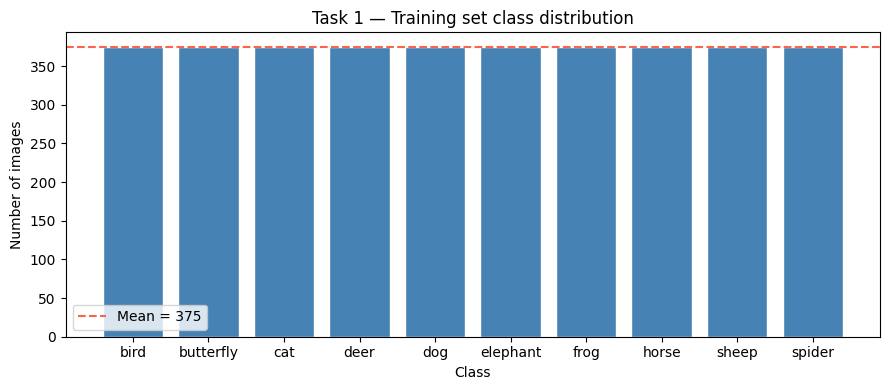

In [98]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
ax.set_title('Task 1 — Training set class distribution')
ax.axhline(class_counts.mean(), color='tomato', linestyle='--', label=f'Mean = {class_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sample Images per Class

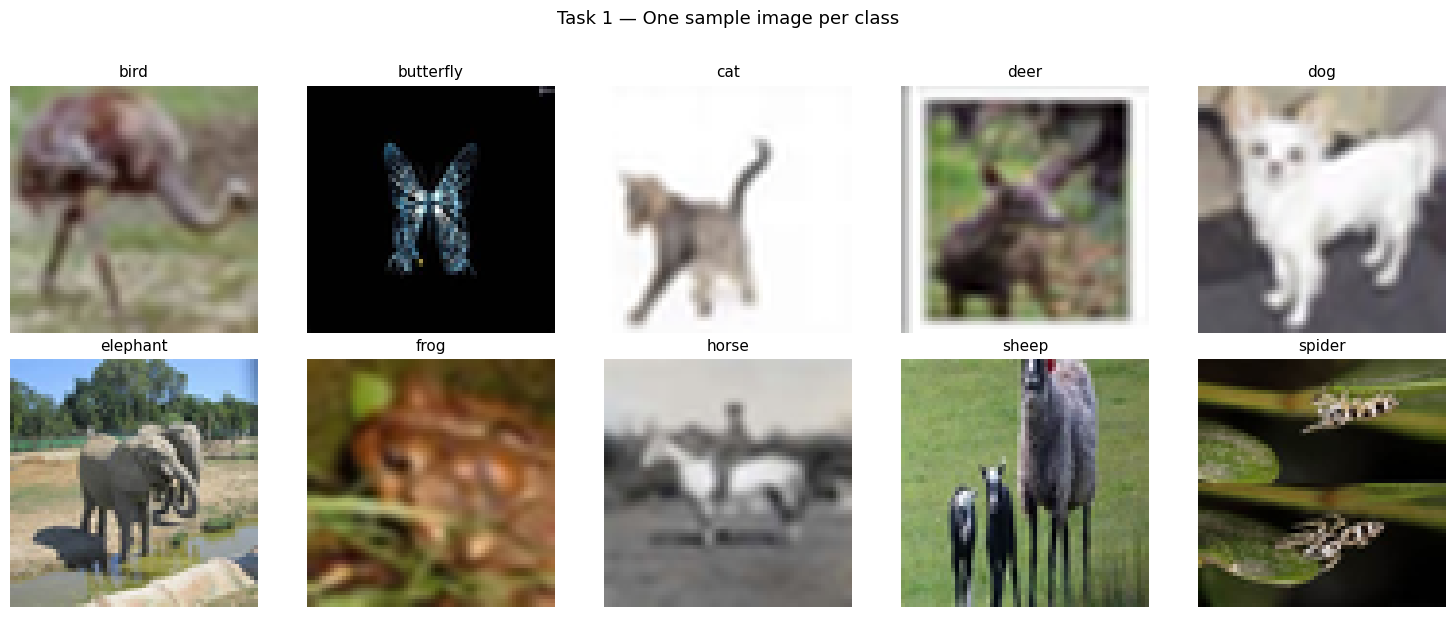

In [99]:
classes = sorted(train_meta['class_name'].unique())
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, cls in zip(axes.flat, classes):
    sample = train_meta[train_meta['class_name'] == cls].iloc[0]
    img = Image.open(DATA_DIR / sample['image_path'])
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.axis('off')

plt.suptitle('Task 1 — One sample image per class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Explore the Provided Features

In [100]:
# Summary statistics for additional_features (most interpretable)
add_feat.describe().round(3)

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,...,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.149,1473.702,0.500,0.483,0.401,0.479,0.188,0.381,0.195,0.191,...,0.413,0.500,0.486,0.413,0.501,0.480,0.390,0.500,0.478,0.389
std,0.070,2144.811,0.140,0.133,0.155,0.131,0.059,0.041,0.061,0.060,...,0.186,0.171,0.166,0.189,0.161,0.153,0.173,0.161,0.152,0.171
min,0.000,8.805,0.001,0.014,0.015,0.038,0.030,0.333,0.007,0.025,...,0.001,0.002,0.007,0.012,0.000,0.018,0.006,0.000,0.010,0.010
25%,0.098,152.454,0.409,0.399,0.294,0.395,0.147,0.353,0.153,0.149,...,0.278,0.382,0.371,0.275,0.389,0.380,0.267,0.391,0.380,0.269
50%,0.137,292.101,0.492,0.477,0.388,0.472,0.185,0.372,0.192,0.188,...,0.391,0.497,0.484,0.392,0.492,0.473,0.369,0.492,0.470,0.369
75%,0.191,2408.836,0.581,0.558,0.487,0.552,0.226,0.399,0.234,0.231,...,0.528,0.611,0.590,0.530,0.605,0.573,0.491,0.603,0.569,0.488
max,0.382,28785.489,0.974,0.959,0.953,0.957,0.410,0.951,0.452,0.431,...,0.994,0.989,0.989,0.988,0.981,0.980,0.973,0.988,0.988,0.987


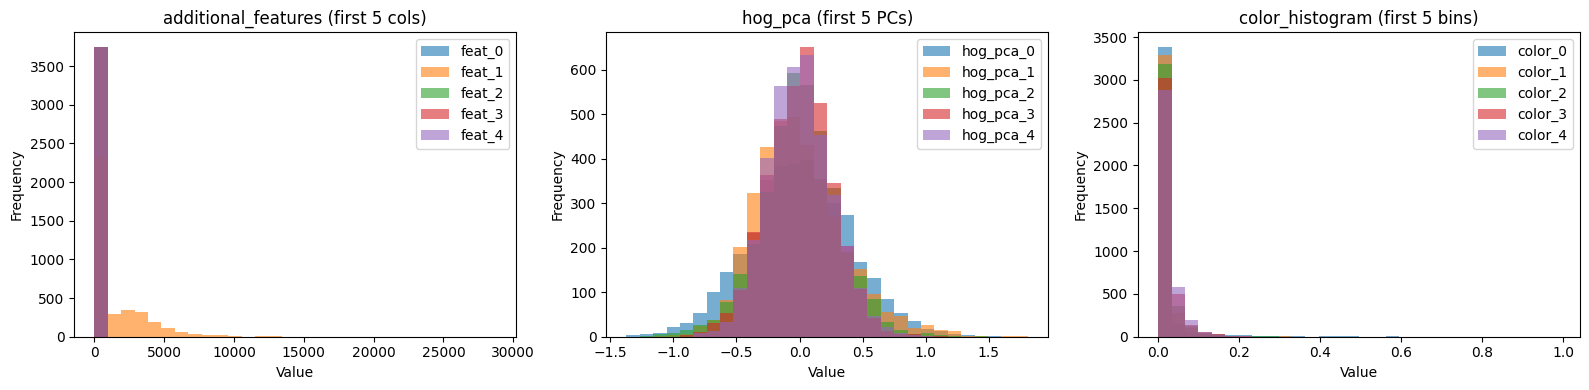

In [101]:
# Distribution of first 5 columns from each feature set
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_ids = train_meta['image_id'].values
add_feat.loc[train_ids].iloc[:, :5].plot(kind='hist', bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('additional_features (first 5 cols)')
axes[0].set_xlabel('Value')

hog_pca.loc[train_ids].iloc[:, :5].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1])
axes[1].set_title('hog_pca (first 5 PCs)')
axes[1].set_xlabel('Value')

color_hist.loc[train_ids].iloc[:, :5].plot(kind='hist', bins=30, alpha=0.6, ax=axes[2])
axes[2].set_title('color_histogram (first 5 bins)')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

In [102]:
# Check feature variance — low-variance columns may not be useful
add_var = add_feat.loc[train_ids].var().sort_values()
print('additional_features — lowest variance columns:')
print(add_var.head(5).round(6))
print('\nadditional_features — highest variance columns:')
print(add_var.tail(5).round(6))

additional_features — lowest variance columns:
feat_7     0.001719
feat_6     0.003446
feat_9     0.003570
feat_8     0.003715
feat_10    0.004796
dtype: float64

additional_features — highest variance columns:
feat_22    2.948100e-02
feat_19    2.991000e-02
feat_13    3.442700e-02
feat_16    3.539500e-02
feat_1     4.575769e+06
dtype: float64


## 7. Feature Engineering

### 7.1 feat_basic — Combine and scale provided features

Concatenate the 3 provided CSVs into one matrix, then apply `StandardScaler`. Scaling is required because kNN and SVM are distance-based — without it, features with large numeric ranges (e.g. `feat_1` variance ~4.5M seen above) would dominate distance calculations and bias the model.

In [103]:
from sklearn.preprocessing import StandardScaler

train_ids = train_meta['image_id'].values
test_ids  = test_meta['image_id'].values

# Concatenate the 3 feature CSVs, aligned by image_id
X_train_raw = pd.concat([
    color_hist.loc[train_ids],
    hog_pca.loc[train_ids],
    add_feat.loc[train_ids],
], axis=1).values

X_test_raw = pd.concat([
    color_hist.loc[test_ids],
    hog_pca.loc[test_ids],
    add_feat.loc[test_ids],
], axis=1).values

y_train = train_meta['class_id'].values

# Fit scaler on train only, then apply to test
scaler_basic  = StandardScaler()
X_train_basic = scaler_basic.fit_transform(X_train_raw)
X_test_basic  = scaler_basic.transform(X_test_raw)

print(f'feat_basic — train : {X_train_basic.shape}  (3750 images × {X_train_basic.shape[1]} features)')
print(f'feat_basic — test  : {X_test_basic.shape}')

feat_basic — train : (3750, 219)  (3750 images × 219 features)
feat_basic — test  : (1250, 219)


### 7.2 feat_combined — Engineer additional features from raw pixels

We extract the mean and standard deviation for each RGB and HSV channel from every raw image (12 values per image). This is cheap to compute but captures information the provided features don't: absolute colour tone (hue, saturation) and per-channel brightness spread — useful for visually distinct classes like grey elephants, green frogs, and colourful butterflies.

In [104]:
import cv2

def extract_pixel_stats(meta_df, data_dir):
    rows = []
    for _, row in meta_df.iterrows():
        img_bgr = cv2.imread(str(data_dir / row['image_path']))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img_hsv = cv2.cvtColor((img_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
        stats = np.concatenate([
            img_rgb.mean(axis=(0, 1)),  # R, G, B mean
            img_rgb.std(axis=(0, 1)),   # R, G, B std
            img_hsv.mean(axis=(0, 1)),  # H, S, V mean
            img_hsv.std(axis=(0, 1)),   # H, S, V std
        ])
        rows.append(stats)
    return np.array(rows)

print('Extracting pixel stats for train...')
train_pixel_stats = extract_pixel_stats(train_meta, DATA_DIR)
print('Extracting pixel stats for test...')
test_pixel_stats  = extract_pixel_stats(test_meta,  DATA_DIR)
print(f'Done — shape: {train_pixel_stats.shape}  (12 features per image)')

Extracting pixel stats for train...
Extracting pixel stats for test...
Done — shape: (3750, 12)  (12 features per image)


In [105]:
# Scale pixel stats (fit on train only), then concatenate with feat_basic
scaler_pixel       = StandardScaler()
train_pixel_scaled = scaler_pixel.fit_transform(train_pixel_stats)
test_pixel_scaled  = scaler_pixel.transform(test_pixel_stats)

X_train_combined = np.concatenate([X_train_basic, train_pixel_scaled], axis=1)
X_test_combined  = np.concatenate([X_test_basic,  test_pixel_scaled],  axis=1)

print(f'feat_combined — train : {X_train_combined.shape}  ({X_train_basic.shape[1]} provided + 12 engineered)')
print(f'feat_combined — test  : {X_test_combined.shape}')

feat_combined — train : (3750, 231)  (219 provided + 12 engineered)
feat_combined — test  : (1250, 231)


### 7.3 PCA visualisation — Do classes separate in feature space?

Reduce `feat_combined` to 2 dimensions to get a visual sense of class separability before training any model. Well-separated clusters suggest the features carry enough signal for classification.

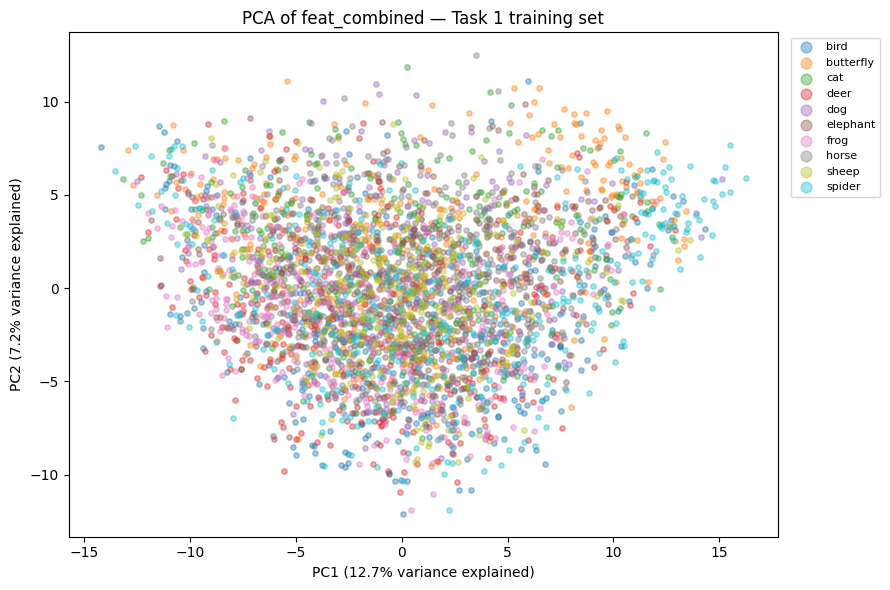

Total variance explained by 2 PCs: 19.9%


In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train_combined)

unique_classes = sorted(np.unique(class_names))
colours = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

fig, ax = plt.subplots(figsize=(9, 6))
for cls, c in zip(unique_classes, colours):
    mask = class_names == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls, alpha=0.4, s=15, color=c)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
ax.set_title('PCA of feat_combined — Task 1 training set')
ax.legend(fontsize=8, markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 8. Models

We evaluate all models using **5-fold stratified cross-validation** on the training set. Stratified means each fold preserves the class ratio — important for fair evaluation. We report mean accuracy ± standard deviation across folds.

We never touch the test set here — it is only used in Section 9 for the final Kaggle submission.

In [107]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []  # collect all results for the summary table at the end

def evaluate(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    mean, std = scores.mean(), scores.std()
    print(f'{name:45s}  acc = {mean:.4f}  ±{std:.4f}')
    results.append({'Model': name, 'Mean Acc': mean, 'Std': std})
    return mean

### 8.1 Model 1 — ZeroR Baseline

Always predicts the majority class regardless of input. This is the absolute floor — any model below this accuracy is worse than doing nothing. With 10 balanced classes of 375 images each, ZeroR should score exactly 10%.

In [108]:
evaluate('ZeroR (majority class)', DummyClassifier(strategy='most_frequent'), X_train_basic, y_train)

ZeroR (majority class)                         acc = 0.1000  ±0.0000


np.float64(0.1)

### 8.2 Model 2 — k-Nearest Neighbours

kNN classifies a point by majority vote among its k nearest neighbours in feature space. We try several values of k to find the best — small k overfits (high variance), large k underfits (high bias). We test both feature sets because kNN is sensitive to the number and scale of features.

In [109]:
for k in [1, 5, 11, 21]:
    evaluate(f'kNN  k={k:<3d}  feat_basic',    KNeighborsClassifier(n_neighbors=k), X_train_basic,    y_train)
    evaluate(f'kNN  k={k:<3d}  feat_combined', KNeighborsClassifier(n_neighbors=k), X_train_combined, y_train)

kNN  k=1    feat_basic                         acc = 0.2448  ±0.0082
kNN  k=1    feat_combined                      acc = 0.2459  ±0.0091
kNN  k=5    feat_basic                         acc = 0.2557  ±0.0097
kNN  k=5    feat_combined                      acc = 0.2605  ±0.0111
kNN  k=11   feat_basic                         acc = 0.2619  ±0.0127
kNN  k=11   feat_combined                      acc = 0.2691  ±0.0175
kNN  k=21   feat_basic                         acc = 0.2485  ±0.0096
kNN  k=21   feat_combined                      acc = 0.2584  ±0.0187


### 8.3 Model 3 — SVM with RBF Kernel

SVM finds the maximum-margin hyperplane separating classes. The RBF kernel maps data into a higher-dimensional space where non-linearly separable classes can be split — well suited to image features where class boundaries are curved. `C` controls the margin/error trade-off; `gamma='scale'` sets the kernel width automatically relative to the number of features.

In [110]:
evaluate('SVM RBF  C=1   feat_basic',    SVC(kernel='rbf', C=1,  gamma='scale', random_state=42), X_train_basic,    y_train)
evaluate('SVM RBF  C=1   feat_combined', SVC(kernel='rbf', C=1,  gamma='scale', random_state=42), X_train_combined, y_train)
evaluate('SVM RBF  C=10  feat_basic',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42), X_train_basic,    y_train)
evaluate('SVM RBF  C=10  feat_combined', SVC(kernel='rbf', C=10, gamma='scale', random_state=42), X_train_combined, y_train)

SVM RBF  C=1   feat_basic                      acc = 0.5040  ±0.0171
SVM RBF  C=1   feat_combined                   acc = 0.5109  ±0.0201
SVM RBF  C=10  feat_basic                      acc = 0.5173  ±0.0290
SVM RBF  C=10  feat_combined                   acc = 0.5253  ±0.0240


np.float64(0.5253333333333333)

### 8.4 Model 4 — SVM with Linear Kernel

The linear kernel finds a straight hyperplane boundary. Counts as a **distinct model** from the RBF SVM per the spec — different kernel = fundamentally different decision boundary shape. Useful for comparison: if linear ≈ RBF, the classes are linearly separable; if RBF >> linear, the boundaries are curved and the kernel trick is doing real work.

In [111]:
evaluate('SVM Linear  C=1   feat_basic',    SVC(kernel='linear', C=1, random_state=42), X_train_basic,    y_train)
evaluate('SVM Linear  C=1   feat_combined', SVC(kernel='linear', C=1, random_state=42), X_train_combined, y_train)

SVM Linear  C=1   feat_basic                   acc = 0.4789  ±0.0159
SVM Linear  C=1   feat_combined                acc = 0.4952  ±0.0133


np.float64(0.4952)

### 8.5 Results Summary Table

In [112]:
results_df = pd.DataFrame(results).sort_values('Mean Acc', ascending=False).reset_index(drop=True)
results_df['Mean Acc'] = results_df['Mean Acc'].map('{:.4f}'.format)
results_df['Std']      = results_df['Std'].map('{:.4f}'.format)
results_df.index += 1  # rank starts at 1
results_df

,Model,Mean Acc,Std
1,SVM RBF C=10 feat_combined,0.5253,0.0240
2,SVM RBF C=10 feat_basic,0.5173,0.0290
3,SVM RBF C=1 feat_combined,0.5109,0.0201
4,SVM RBF C=1 feat_basic,0.5040,0.0171
5,SVM Linear C=1 feat_combined,0.4952,0.0133
6,SVM Linear C=1 feat_basic,0.4789,0.0159
7,kNN k=11 feat_combined,0.2691,0.0175
8,kNN k=11 feat_basic,0.2619,0.0127
9,kNN k=5 feat_combined,0.2605,0.0111
10,kNN k=21 feat_combined,0.2584,0.0187


## 9. Error Analysis

Best model: **SVM RBF C=10, feat_combined**. We use `cross_val_predict` to obtain out-of-fold predictions for every training image — each image is predicted by a model that was never trained on it, giving a realistic picture of errors without using the test set.

### 9.1 Confusion Matrix

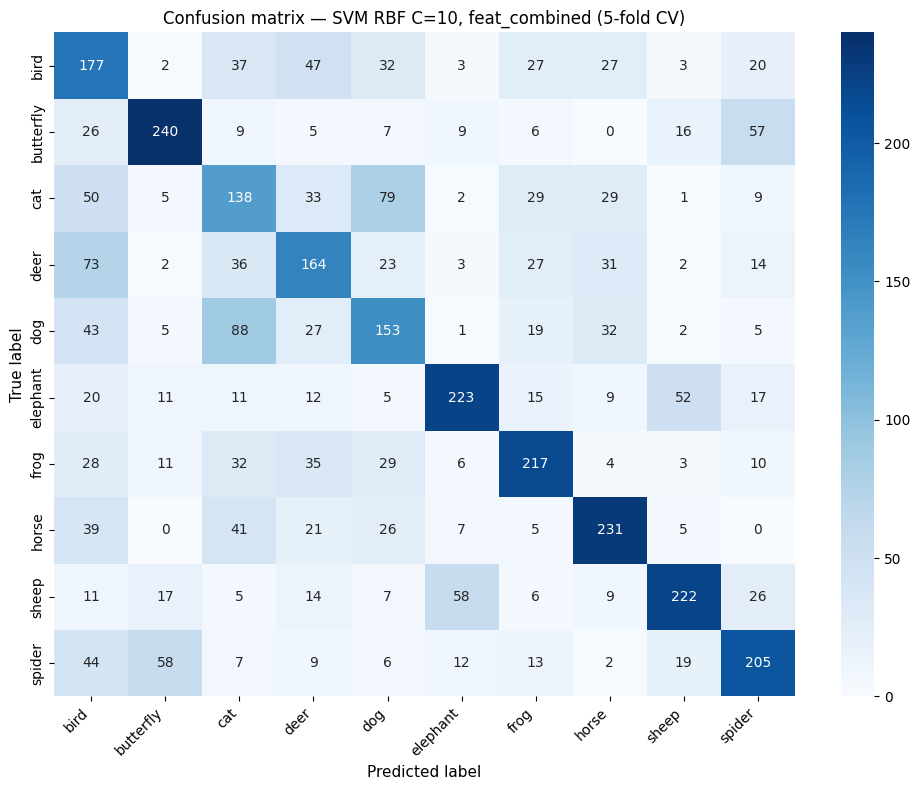

In [113]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

best_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
y_pred_cv  = cross_val_predict(best_model, X_train_combined, y_train, cv=cv)

# Class labels in class_id order (0–9)
class_labels = (train_meta.drop_duplicates('class_id')
                           .sort_values('class_id')['class_name']
                           .tolist())

cm = confusion_matrix(y_train, y_pred_cv)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('Confusion matrix — SVM RBF C=10, feat_combined (5-fold CV)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.2 Per-Class Accuracy & Most Confused Pairs

In [114]:
# Per-class accuracy (diagonal / row sum)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_df = pd.DataFrame({'Class': class_labels, 'Accuracy': per_class_acc}).sort_values('Accuracy')
print('Per-class accuracy (worst → best):')
print(acc_df.to_string(index=False))

# Top confused pairs (off-diagonal with highest counts)
print('\nTop 5 most confused pairs:')
rows, cols = np.where(np.eye(len(class_labels)) == 0)
pairs = [(cm[r, c], class_labels[r], class_labels[c]) for r, c in zip(rows, cols)]
pairs.sort(reverse=True)
for count, true_cls, pred_cls in pairs[:5]:
    print(f'  True: {true_cls:12s}  →  Predicted: {pred_cls:12s}  ({count} times)')

Per-class accuracy (worst → best):
    Class  Accuracy
      cat  0.368000
      dog  0.408000
     deer  0.437333
     bird  0.472000
   spider  0.546667
     frog  0.578667
    sheep  0.592000
 elephant  0.594667
    horse  0.616000
butterfly  0.640000

Top 5 most confused pairs:
  True: dog           →  Predicted: cat           (88 times)
  True: cat           →  Predicted: dog           (79 times)
  True: deer          →  Predicted: bird          (73 times)
  True: spider        →  Predicted: butterfly     (58 times)
  True: sheep         →  Predicted: elephant      (58 times)


### 9.3 Misclassified Images

Displaying misclassified examples side by side — the true label is in the title (top) and the predicted label below it. This helps identify whether errors are caused by genuinely ambiguous images or systematic feature failures.

Total misclassified: 1780 / 3750  (47.5%)


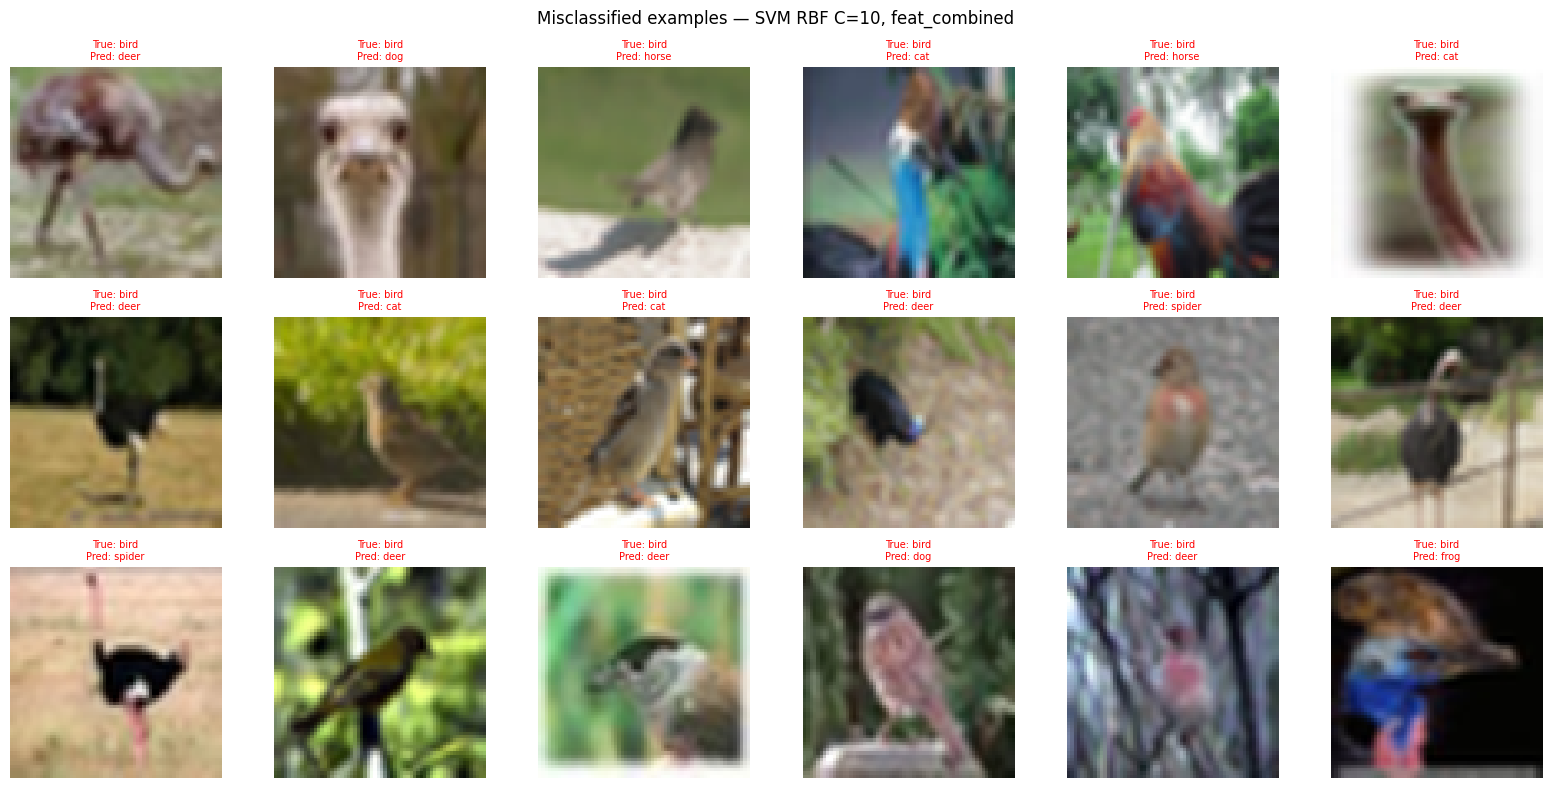

In [115]:
id_to_name = dict(zip(train_meta['class_id'], train_meta['class_name']))
misclassified_idx = np.where(y_pred_cv != y_train)[0]
print(f'Total misclassified: {len(misclassified_idx)} / {len(y_train)}  ({len(misclassified_idx)/len(y_train)*100:.1f}%)')

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for ax, idx in zip(axes.flat, misclassified_idx[:18]):
    row = train_meta.iloc[idx]
    img = Image.open(DATA_DIR / row['image_path'])
    ax.imshow(img)
    true_cls = id_to_name[y_train[idx]]
    pred_cls = id_to_name[y_pred_cv[idx]]
    ax.set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=7,
                 color='red' if true_cls != pred_cls else 'green')
    ax.axis('off')

plt.suptitle('Misclassified examples — SVM RBF C=10, feat_combined', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Kaggle Submission

Fit the best model on **all** 3750 training images (not just a fold), predict the 1250 test images, and save the CSV.

In [116]:
best_model.fit(X_train_combined, y_train)
y_test_pred = best_model.predict(X_test_combined)

submission = pd.DataFrame({
    'image_id':   test_meta['image_id'],
    'class_name': [id_to_name[i] for i in y_test_pred]
})
submission.to_csv('task1_submission.csv', index=False)
print(f'Saved task1_submission.csv  ({len(submission)} rows)')
submission['class_name'].value_counts()

Saved task1_submission.csv  (1250 rows)


class_name
bird         197
frog         144
dog          126
butterfly    124
deer         120
horse        116
cat          113
spider       108
sheep        108
elephant      94
Name: count, dtype: int64